# Modeling 


## Objective

Now that the data is clean and preprocessed, it is time to let the algorithm 
do its thing. In this notebook I will train a KMeans clustering model to group 
songs by their lyrical mood and content.

# Goal
is simple find natural groups in the data so that when a user 
listens to a song, the algorithm can say "this song belongs to this cluster" 
and recommend other songs that feel the same way.

In [17]:
#import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle

In [18]:
#let's load the original dataset Large_data.cvs

df_original= pd.read_csv('/Users/ingxrodriguez/Documents/Music_recomendation/Dataset/Large_data.csv')    


In [19]:
df_original.shape

(28362, 24)

In [21]:
#load  dataset pca processed
df_pca = pd.read_csv('data_preprocessed.csv')
print(f"Loaded PCA data shape: {df_pca.shape}")

Loaded PCA data shape: (28362, 12)


In [22]:
#let's convert df_pca to X 
X = df_pca.values
print(f"X shape: {X.shape}")  

X shape: (28362, 12)


## Finding the Optimal K — Elbow Method

Before training the model I need to decide how many clusters to create. 
To do this I used the **`Elbow Method`**, which runs KMeans for different values 
of K and measures the inertia each time.

Inertia measures how spread out the songs are inside each cluster. 
The higher the inertia the more scattered the songs are. As we increase K 
the inertia always goes down but at some point adding more clusters 
stops making a real difference. That point is the elbow and that is our optimal K.

k= 2 | inertia=347702.7
k= 3 | inertia=321160.5
k= 4 | inertia=296598.3
k= 5 | inertia=273210.1
k= 6 | inertia=252426.6
k= 7 | inertia=231139.0
k= 8 | inertia=217659.1
k= 9 | inertia=209378.1
k=10 | inertia=192404.4
k=11 | inertia=182215.5
k=12 | inertia=172527.1
k=13 | inertia=165810.4
k=14 | inertia=162973.0
k=15 | inertia=160645.3


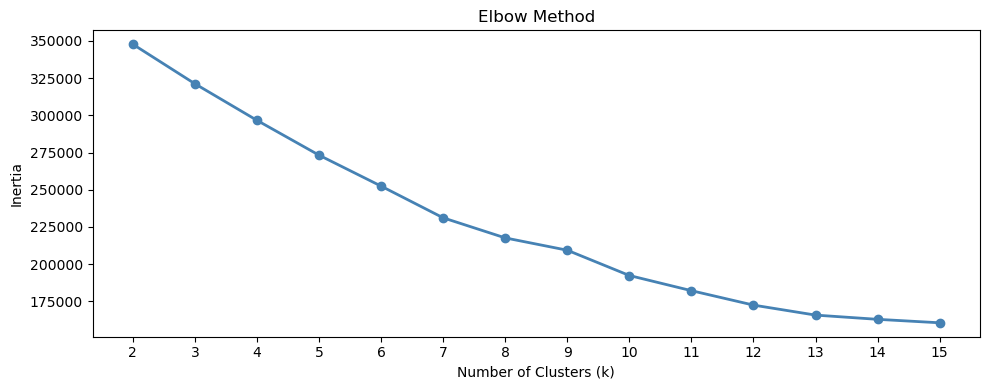

In [23]:
#CALCULATE INERTIA FOR K-MEANS CLUSTERING WITH ELBOW METHOD
inertias = []
K_RANGE = range(2, 16)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"k={k:2d} | inertia={km.inertia_:.1f}")

plt.figure(figsize=(10, 4))
plt.plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

The elbow is not very clear, but if there is one it falls somewhere between 
k=7 and k=10. Because of this I will use the **`Silhouette Score`** to find a 
more precise answer.

k= 2 | silhouette=0.1067
k= 3 | silhouette=0.1118
k= 4 | silhouette=0.1345
k= 5 | silhouette=0.1607
k= 6 | silhouette=0.1853
k= 7 | silhouette=0.2055
k= 8 | silhouette=0.2104
k= 9 | silhouette=0.1953
k=10 | silhouette=0.2206
k=11 | silhouette=0.2192
k=12 | silhouette=0.2177
k=13 | silhouette=0.2066
k=14 | silhouette=0.1959
k=15 | silhouette=0.1794


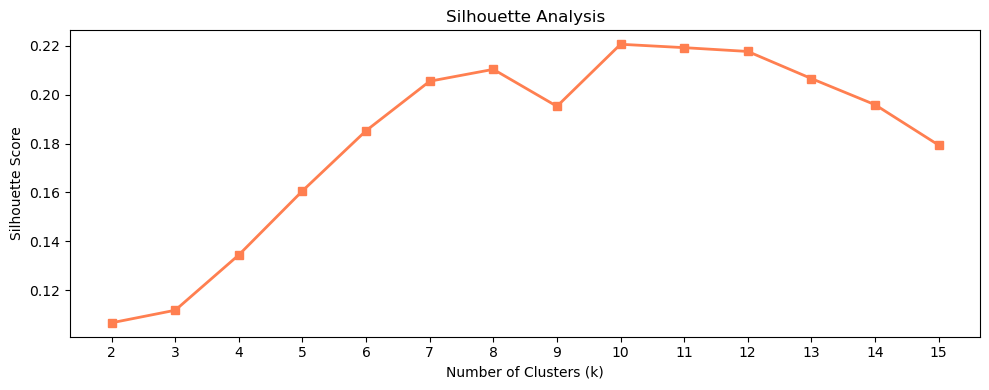

In [24]:
# Calculate silhouette scores for each k

sil_scores = []
K_RANGE = range(2, 16)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f"k={k:2d} | silhouette={score:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(list(K_RANGE), sil_scores, 's-', color='coral', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

## Training the Model

After running the model with k=10, I can see that clusters 2 and 5 are the 
largest with around 5,000 songs each, while clusters 1 and 4 are the smallest 
with around 900 songs. This makes sense because in real life some moods and 
lyrical themes are more common than others.

The inertia came out at 192,404 which compared to k=2 where it was around 
345,000 is a significant improvement. This confirms that k=10 is doing a 
much better job at grouping similar songs together.

In [25]:
# Train final KMeans model.
BEST_K = 10

km_final = KMeans(n_clusters=BEST_K, init='k-means++', 
                  n_init=20, max_iter=500, random_state=42)
km_final.fit(X)
labels = km_final.labels_

print(f"Model trained with k={BEST_K}")
print(f"Inertia: {km_final.inertia_:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(labels).value_counts().sort_index())

Model trained with k=10
Inertia: 192404.33

Cluster distribution:
0    4335
1     948
2    5191
3    2266
4     882
5    5361
6     968
7    4837
8    1865
9    1709
Name: count, dtype: int64


In [26]:
#let's take the labels from the original data and add them to better understand the clusters
df_original['cluster'] = labels

print("Genre distribution per cluster:")
print(df_original.groupby('cluster')['genre'].value_counts().unstack(fill_value=0))

Genre distribution per cluster:
genre    blues  country  hip hop  jazz   pop  reggae  rock
cluster                                                   
0          471      557      673   596  1080     626   332
1          167       96       28   114   270     116   157
2          972      625       97   620  1129     537  1211
3          427      575       15   411   495     129   214
4          222      211        7    99   178      75    90
5          770     1424       31   624  1475     239   798
6          288      146        6   114   260      66    88
7          629     1059       36   694  1202     510   707
8          344      377        8   224   484     145   283
9          313      374        3   348   465      54   152


In [27]:
#check the average of the features per cluster to understand the characteristics of each cluster

lyric_features = ['dating','violence','world/life','night/time',
                  'shake the audience','family/gospel','romantic',
                  'communication','obscene','music','movement/places',
                  'light/visual perceptions','sadness']

profiles = df_original.groupby('cluster')[lyric_features].mean()
print(profiles.round(3))

         dating  violence  world/life  night/time  shake the audience  \
cluster                                                                 
0         0.015     0.054       0.043       0.026               0.018   
1         0.019     0.112       0.100       0.045               0.182   
2         0.009     0.432       0.054       0.031               0.010   
3         0.014     0.037       0.048       0.031               0.010   
4         0.017     0.107       0.106       0.047               0.014   
5         0.014     0.038       0.056       0.034               0.010   
6         0.234     0.058       0.093       0.057               0.017   
7         0.010     0.044       0.428       0.032               0.010   
8         0.021     0.042       0.049       0.398               0.013   
9         0.019     0.027       0.070       0.039               0.010   

         family/gospel  romantic  communication  obscene  music  \
cluster                                                 

## Cluster Lyrical Profiles

The heatmap makes it easy to see what makes each cluster unique. 
Every cluster has one dominant lyrical theme that stands out in dark red. 
Cluster 0 is clearly the explicit cluster, Cluster 2 is the most violent, 
and Cluster 9 groups the romantic songs together. 

This is exactly what I hypothesized — the algorithm grouped songs by 
emotional mood rather than genre, and the results make intuitive sense.

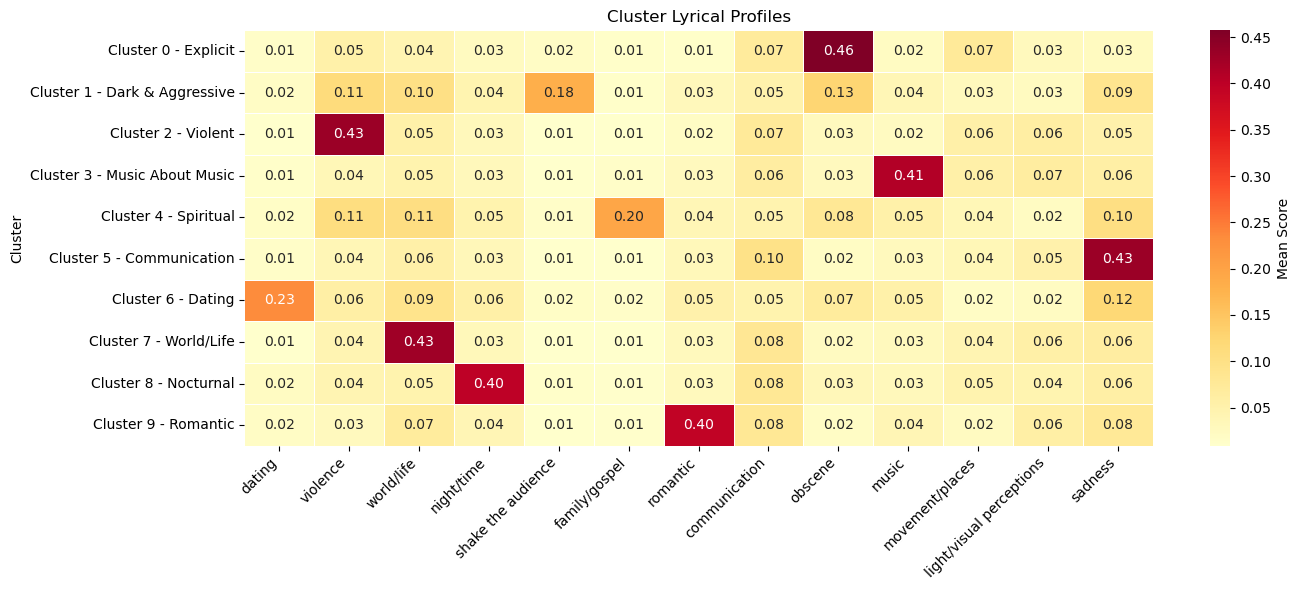

In [29]:
# Visualize the cluster profiles using a heatmap
cluster_names = {
    0: 'Cluster 0 - Explicit',
    1: 'Cluster 1 - Dark & Aggressive',
    2: 'Cluster 2 - Violent',
    3: 'Cluster 3 - Music About Music',
    4: 'Cluster 4 - Spiritual',
    5: 'Cluster 5 - Communication',
    6: 'Cluster 6 - Dating',
    7: 'Cluster 7 - World/Life',
    8: 'Cluster 8 - Nocturnal',
    9: 'Cluster 9 - Romantic'
}

profiles.index = [cluster_names[i] for i in profiles.index]

plt.figure(figsize=(14, 6))
sns.heatmap(profiles, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean Score'})
plt.title('Cluster Lyrical Profiles')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
# Save the final KMeans model to a file using pickle
with open('kmeans_model.pkl', 'wb') as f: 
    pickle.dump(km_final, f)
print("Saved kmeans_model.pkl")

Saved kmeans_model.pkl


In [31]:
#save original data with cluster labels
df_original.to_csv('data_clustered.csv', index=False)
print("Saved data_clustered.csv")

Saved data_clustered.csv


In [32]:
df_original.shape

(28362, 25)